In [41]:
pip install numpy pandas scikit-learn pickle stremlit

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for pickle


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

In [43]:
cars_data = pd.read_csv(r"C:\Users\Madhurima\Downloads\Car Price prediction Model\Cardetails.csv")

In [44]:
print("Original dataset shape:", cars_data.shape)
print("\nFirst few rows of the dataset:")
print(cars_data.head())

Original dataset shape: (8128, 13)

First few rows of the dataset:
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner     mileage   engine   max_power  \
0  Individual       Manual   First Owner   23.4 kmpl  1248 CC      74 bhp   
1  Individual       Manual  Second Owner  21.14 kmpl  1498 CC  103.52 bhp   
2  Individual       Manual   Third Owner   17.7 kmpl  1497 CC      78 bhp   
3  Individual       Manual   First Owner   23.0 kmpl  1396 CC      90 bhp   
4  Individual       Manual   First Owner   16.1 kmpl  1298 CC    88.2 bhp   

                   

In [45]:
# Check for missing values
print("\nMissing values in each column:")
print(cars_data.isnull().sum())


Missing values in each column:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64


In [46]:
# Drop rows with missing values
cars_data.dropna(inplace=True)
print(f"\nDataset shape after dropping missing values: {cars_data.shape}")


Dataset shape after dropping missing values: (7906, 13)


In [47]:
# Remove duplicates
cars_data.drop_duplicates(inplace=True)
print(f"Dataset shape after removing duplicates: {cars_data.shape}")

Dataset shape after removing duplicates: (6717, 13)


In [48]:
# Drop torque column as it's not needed
if 'torque' in cars_data.columns:
    cars_data.drop(columns=['torque'], inplace=True)

In [49]:
# Filter out rows with zero or negative selling prices
cars_data = cars_data[cars_data['selling_price'] > 0]
print(f"Dataset shape after removing zero/negative prices: {cars_data.shape}")

Dataset shape after removing zero/negative prices: (6717, 12)


In [50]:
# Extract brand name from car name
def get_brand_name(car_name):
    return car_name.split(' ')[0].strip()

In [51]:
cars_data['brand'] = cars_data['name'].apply(get_brand_name)

In [52]:
# Clean numeric fields
def clean_numeric(value):
    if pd.isna(value) or value is None:
        return 0
    if isinstance(value, str):
        # Extract the numeric part
        value = value.split()[0].strip()
        if value == '':
            return 0
        try:
            return float(value)
        except ValueError:
            return 0
    return float(value)

In [53]:
# Apply cleaning to numeric columns
cars_data['mileage'] = cars_data['mileage'].apply(clean_numeric)
cars_data['engine'] = cars_data['engine'].apply(clean_numeric)
cars_data['max_power'] = cars_data['max_power'].apply(clean_numeric)

In [54]:
# Handle outliers in numeric columns
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [55]:
# Remove outliers from key numeric columns
for column in ['km_driven', 'mileage', 'engine', 'max_power', 'selling_price']:
    cars_data = remove_outliers(cars_data, column)

print(f"Dataset shape after removing outliers: {cars_data.shape}")

Dataset shape after removing outliers: (5119, 13)


In [56]:
# Feature engineering
# Calculate car age from year
current_year = 2025  # Update this to the current year
cars_data['car_age'] = current_year - cars_data['year']

In [57]:
# Visualize the relationship between key features and selling price
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'Year vs Price')

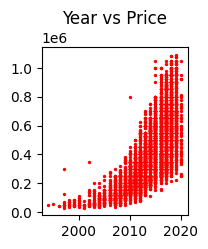

In [58]:
plt.subplot(2, 3, 1)
plt.scatter(cars_data['year'], cars_data['selling_price'], color = 'red', s=2)
plt.title('Year vs Price')

Text(0.5, 1.0, 'Kilometers Driven vs Price')

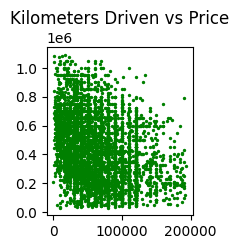

In [59]:
plt.subplot(2, 3, 2)
plt.scatter(cars_data['km_driven'], cars_data['selling_price'], color = 'green', s=2)
plt.title('Kilometers Driven vs Price')

Text(0.5, 1.0, 'Mileage vs Price')

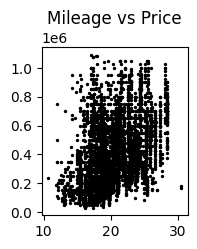

In [60]:
plt.subplot(2, 3, 3)
plt.scatter(cars_data['mileage'], cars_data['selling_price'], color = 'black', s=2)
plt.title('Mileage vs Price')

Text(0.5, 1.0, 'Engine CC vs Price')

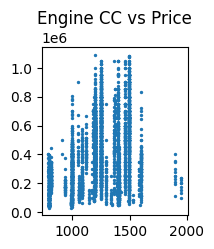

In [61]:
plt.subplot(2, 3, 4)
plt.scatter(cars_data['engine'], cars_data['selling_price'], s=2)
plt.title('Engine CC vs Price')

Text(0.5, 1.0, 'Max Power vs Price')

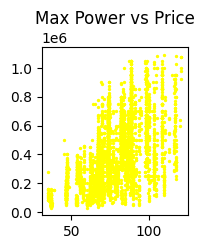

In [62]:
plt.subplot(2, 3, 5)
plt.scatter(cars_data['max_power'], cars_data['selling_price'], color = 'yellow', s=2)
plt.title('Max Power vs Price')

In [63]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [64]:
# Prepare data for modeling
# Separate features and target
X = cars_data.drop(['selling_price', 'name'], axis=1)  # Drop name as we've created brand
y = cars_data['selling_price']

In [65]:
# Identify categorical and numerical columns
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
numerical_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'car_age']

In [66]:
# Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
# Create preprocessing pipelines for both numerical and categorical data
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [68]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [69]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [70]:
# Create and train the model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [71]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'km_driven',
                                                   'mileage', 'engine',
                                                   'max_power', 'seats',
                                                   'car_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['fuel', 'seller_type',
                                                   'transmission', 'owner',
                                                   'brand'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [72]:
# Make predictions
y_pred = model.predict(X_test)

In [73]:
# Ensure predictions are never less than ₹50,000
y_pred = np.maximum(y_pred, 50000)

In [74]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [75]:
print("\nModel Evaluation:")
print(f"Mean Absolute Error: ₹{mae:.2f}")
print(f"Root Mean Squared Error: ₹{rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Model Evaluation:
Mean Absolute Error: ₹50978.36
Root Mean Squared Error: ₹70621.16
R² Score: 0.9019


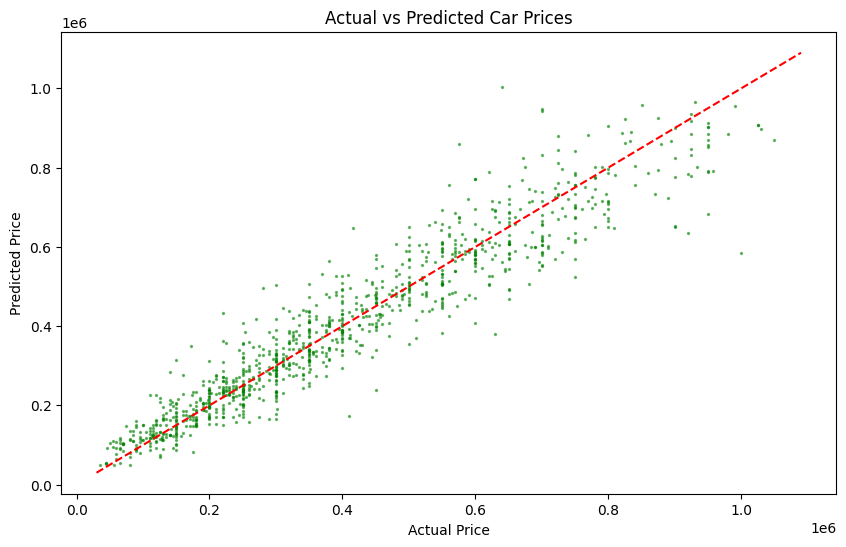

In [76]:
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color = 'green', s=2)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()


Feature ranking:
1. car_age (0.2976)
2. year (0.2777)
3. max_power (0.2548)
4. km_driven (0.0407)
5. engine (0.0374)
6. mileage (0.0345)
7. brand_Tata (0.0076)
8. seats (0.0060)
9. brand_Toyota (0.0046)
10. brand_Maruti (0.0044)


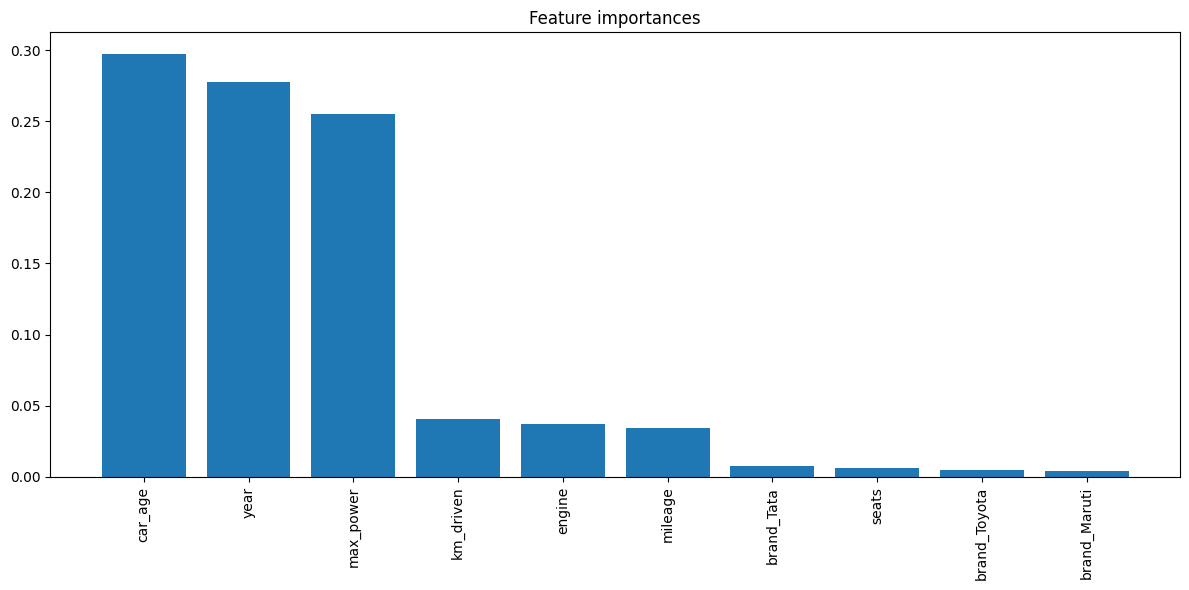

In [77]:
# Feature importance
if hasattr(model['regressor'], 'feature_importances_'):
    # Get feature names after one-hot encoding
    ohe = model['preprocessor'].named_transformers_['cat']['onehot']
    cat_feature_names = ohe.get_feature_names_out(categorical_cols)
    feature_names = list(numerical_cols) + list(cat_feature_names)
    
    # Get feature importances
    importances = model['regressor'].feature_importances_
    
    # Sort feature importances in descending order
    indices = np.argsort(importances)[::-1]
    
    # Print the feature ranking
    print("\nFeature ranking:")
    for f in range(min(10, len(feature_names))):  # Print top 10 features
        print(f"{f+1}. {feature_names[indices[f]]} ({importances[indices[f]]:.4f})")
    
    # Plot feature importances
    plt.figure(figsize=(12, 6))
    plt.title("Feature importances")
    plt.bar(range(min(10, len(feature_names))), 
            importances[indices[:10]],
            align="center")
    plt.xticks(range(min(10, len(feature_names))), 
              [feature_names[i] for i in indices[:10]], 
              rotation=90)
    plt.tight_layout()
    plt.show()

In [78]:
# Save the model
with open('car_price_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("\nModel saved as 'car_price_model.pkl'")


Model saved as 'car_price_model.pkl'


In [79]:
# Example of how to use the model for prediction
print("\nExample prediction:")
# Create a sample input
sample_input = pd.DataFrame({
    'year': [2018],
    'km_driven': [45000],
    'fuel': ['Petrol'],  # Original categorical value
    'seller_type': ['Individual'],  # Original categorical value
    'transmission': ['Manual'],  # Original categorical value
    'owner': ['First Owner'],  # Original categorical value
    'mileage': [21.5],
    'engine': [1197],
    'max_power': [82.0],
    'seats': [5],
    'brand': ['Maruti'],  # Original categorical value
    'car_age': [7]  # 2025 - 2018
})

# Make prediction
prediction = model.predict(sample_input)[0]
# Apply minimum price constraint
prediction = max(prediction, 50000)

print(f"Predicted price for the sample car: ₹{prediction:,.2f}")


Example prediction:
Predicted price for the sample car: ₹540,733.14


In [80]:
# Function to make predictions with the saved model
def predict_car_price(model_path, input_data):
    """
    Make car price predictions using the saved model
    
    Parameters:
    model_path (str): Path to the saved model file
    input_data (DataFrame): Input data for prediction
    
    Returns:
    float: Predicted car price
    """
    # Load the model
    with open(model_path, 'rb') as file:
        loaded_model = pickle.load(file)
    
    # Make prediction
    prediction = loaded_model.predict(input_data)[0]
    
    # Apply minimum price constraint
    prediction = max(prediction, 50000)
    
    return prediction

print("\nUsing the saved model function:")
saved_model_prediction = predict_car_price('car_price_model.pkl', sample_input)
print(f"Predicted price using saved model: ₹{saved_model_prediction:,.2f}")


Using the saved model function:
Predicted price using saved model: ₹540,733.14
